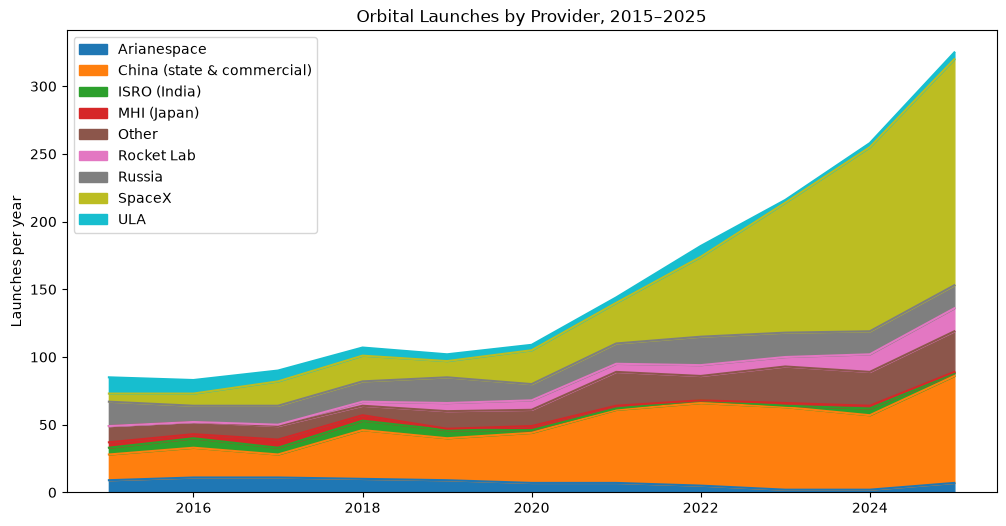

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("gcat.duckdb")

df = con.execute("""
    SELECT launch_year, provider, COUNT(*) AS launches
    FROM launches_named
    WHERE launch_year BETWEEN 2015 AND 2025
    GROUP BY launch_year, provider
    ORDER BY launch_year
""").df()

pivot = df.pivot(index="launch_year", columns="provider", values="launches").fillna(0)

pivot.plot(kind="area", stacked=True, figsize=(12, 6), colormap="tab10")
plt.title("Orbital Launches by Provider, 2015–2025")
plt.ylabel("Launches per year")
plt.xlabel("")
plt.legend(title=None, loc="upper left")
plt.show()

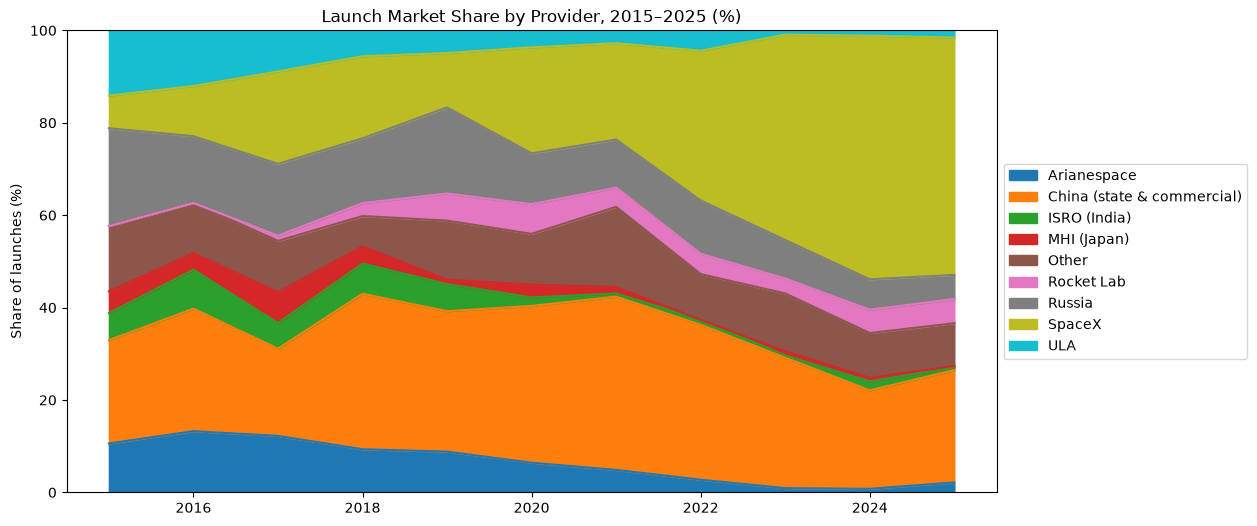

In [2]:
# Convert each year's counts to % of that year's total (each row sums to 100)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 100%-stacked area: shows SHARE shifts, ignoring market growth
pivot_pct.plot(kind="area", stacked=True, figsize=(12, 6), colormap="tab10")
plt.title("Launch Market Share by Provider, 2015–2025 (%)")
plt.ylabel("Share of launches (%)")
plt.xlabel("")
plt.ylim(0, 100)                     # lock axis to 0-100
plt.legend(title=None, loc="center left", bbox_to_anchor=(1, 0.5))  # legend outside the plot
plt.show()

In [13]:
con.execute("SELECT COUNT(*) FROM payloads").df()

,count_star()
0,27852


In [14]:
con.execute("SELECT * FROM payloads LIMIT 10").df()

,jcat_id,cospar_id,payload_name,launch_tag,launch_date,owner_code,state_code,manufacturer_code,mass_kg,mass_is_estimate,orbit_category
0,S00002,1957 ALP 2,1-y ISZ,None,1957-10-04,OKB1,SU,OKB1,84.0,False,LLEO/I
1,S00003,1957 BET 1,2-y ISZ,None,1957-11-03,OKB1,SU,OKB1,508.0,False,LEO/I
2,S00004,1958 ALP,Explorer I,None,1958-02-01,ABMA/JPLA,US,JPLA,8.0,False,LEO/I
3,S00005,1958 BET 2,Vanguard I,None,1958-03-17,NRL,US,NRL,2.0,False,MEO
4,S00006,1958 GAM,Explorer III,None,1958-03-26,ABMA/JPLA,US,JPLA,8.0,False,LEO/I
5,S00008,1958 DEL 2,3-y Sovetskiy ISZ,None,1958-05-15,OKB1,SU,OKB1,1327.0,False,LEO/I
6,S00009,1958 EPS,Explorer IV,None,1958-07-26,ABMA/JPLA,US,JPLA,12.0,False,LEO/I
7,S00010,1958 ZET,SCORE,None,1958-12-18,ARPA/SCEL,US,SCEL,68.0,False,LEO/I
8,S00011,1959 ALP 1,Vanguard II,None,1959-02-17,BSC,US,NRL,10.0,False,LEO/I
9,S00013,1959 BET,Discoverer 1,None,1959-02-28,ARPA/CIA,US,LMSD,78.0,True,LLEO/P


In [15]:
con.execute("SELECT COUNT(mass_kg) FROM payloads").df()

,count(mass_kg)
0,27852


In [19]:
con.execute("SELECT COUNT(DISTINCT owner_code) FROM payloads").df()

,count(DISTINCT owner_code)
0,1948


In [21]:
con.execute("""
SELECT COUNT(*) FROM payloads""").df()

,count_star()
0,27852


In [23]:
con.execute("""SELECT COUNT(*) AS Number_Launches FROM launches""").df()

,Number_Launches
0,7124


In [25]:
con.execute("""SELECT *
FROM payloads LIMIT 5""").df()

,jcat_id,cospar_id,payload_name,launch_tag,launch_date,owner_code,state_code,manufacturer_code,mass_kg,mass_is_estimate,orbit_category
0,S00002,1957 ALP 2,1-y ISZ,None,1957-10-04,OKB1,SU,OKB1,84.0,False,LLEO/I
1,S00003,1957 BET 1,2-y ISZ,None,1957-11-03,OKB1,SU,OKB1,508.0,False,LEO/I
2,S00004,1958 ALP,Explorer I,None,1958-02-01,ABMA/JPLA,US,JPLA,8.0,False,LEO/I
3,S00005,1958 BET 2,Vanguard I,None,1958-03-17,NRL,US,NRL,2.0,False,MEO
4,S00006,1958 GAM,Explorer III,None,1958-03-26,ABMA/JPLA,US,JPLA,8.0,False,LEO/I


In [26]:
con.execute("""SELECT *
FROM launches LIMIT 5""").df()

,launch_tag,launch_date,launch_year,vehicle,agency_code,site_code,pad,outcome_code,success
0,1957 ALP,1957-10-04,1957,Sputnik 8K71PS,MVS,NIIP-5,LC1,S,True
1,1957 BET,1957-11-03,1957,Sputnik 8K71PS,MVS,NIIP-5,LC1,S,True
2,1957-F01,1957-12-06,1957,Vanguard,NRL,CC,LC18A,F,False
3,1958 ALP,1958-02-01,1958,Jupiter C,ABMA,CC,LC26A,S,True
4,1958-F01,1958-02-05,1958,Vanguard,NRL,CC,LC18A,F,False


In [49]:
con.execute("""
SELECT agency_code, COUNT(*) AS launch_count
FROM launches
GROUP BY agency_code
ORDER BY launch_count desc
LIMIT 10""").df()

,agency_code,launch_count
0,RVSN,1486
1,UNKS,899
2,SPX,678
3,CALT,365
4,AE,299
5,SAST,272
6,AFSSD,243
7,VKSR,197
8,FKA,185
9,GSFC,175


In [51]:
con.execute("""
SELECT *
FROM launches
ORDER BY launch_date""").df()

,launch_tag,launch_date,launch_year,vehicle,agency_code,site_code,pad,outcome_code,success
0,1957 ALP,1957-10-04,1957,Sputnik 8K71PS,MVS,NIIP-5,LC1,S,True
1,1957 BET,1957-11-03,1957,Sputnik 8K71PS,MVS,NIIP-5,LC1,S,True
2,1957-F01,1957-12-06,1957,Vanguard,NRL,CC,LC18A,F,False
3,1958 ALP,1958-02-01,1958,Jupiter C,ABMA,CC,LC26A,S,True
4,1958-F01,1958-02-05,1958,Vanguard,NRL,CC,LC18A,F,False
...,...,...,...,...,...,...,...,...,...
7119,2026-155,2026-07-05,2026,Chang Zheng 8A,ZHSH/CALT,HCSLS,LC1,S,True
7120,2026-156,2026-07-07,2026,Falcon 9,SPX,VSFBS,SLC4E,S,True
7121,2026-157,2026-07-09,2026,Falcon 9,SPX,CC,LC40,S,True
7122,2026-158,2026-07-10,2026,Chang Zheng 10B,CALT,HCSLS,LC2,S,True


In [54]:
con.execute("""
SELECT MAX(launch_date) AS Most_recent_launch, MIN(launch_date) AS Earliest_launch
FROM launches""").df()

,Most_recent_launch,Earliest_launch
0,2026-07-11,1957-10-04


In [60]:
con.execute("""
SELECT state_code, COUNT(*)
FROM payloads
GROUP BY state_code
ORDER BY COUNT(*) desc""").df()

,state_code,count_star()
0,US,17607
1,SU,3347
2,CN,1985
3,RU,1228
4,UK,824
...,...,...
117,HR,1
118,JO,1
119,BO,1
120,GH,1


In [62]:
con.execute("""
SELECT agency_code, COUNT(*)
FROM launches
WHERE agency_code = 'MVS'
GROUP BY agency_code""").df()


,agency_code,count_star()
0,MVS,8


<Axes: xlabel='launch_year'>

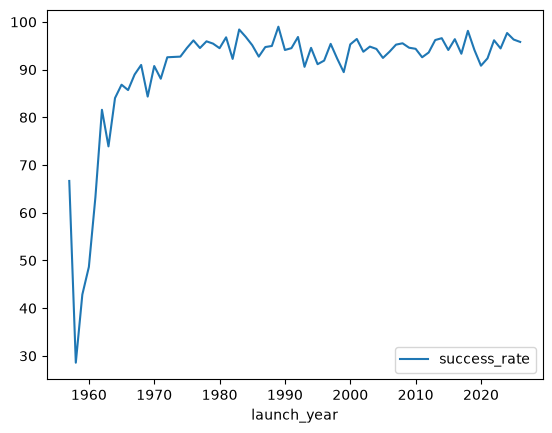

In [67]:
df = con.execute("""
SELECT launch_year,SUM(CASE WHEN success THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS success_rate, COUNT(*) AS numLaunches
FROM launches
GROUP BY launch_year
ORDER BY launch_year
""").df()

df.plot(kind='line',x="launch_year", y="success_rate")

In [68]:
con.execute("""SELECT COUNT(*) FROM payloads WHERE mass_kg IS NULL""").df()

,count_star()
0,0


In [70]:
con.execute("""SELECT COUNT(*) FROM payloads WHERE mass_is_estimate = True""").df()

,count_star(),count_star()_1
0,4334,4334


In [71]:
con.execute("""SELECT COUNT(*) FROM payloads""").df()

,count_star()
0,27852


In [72]:
4334/27852

0.15560821484992102

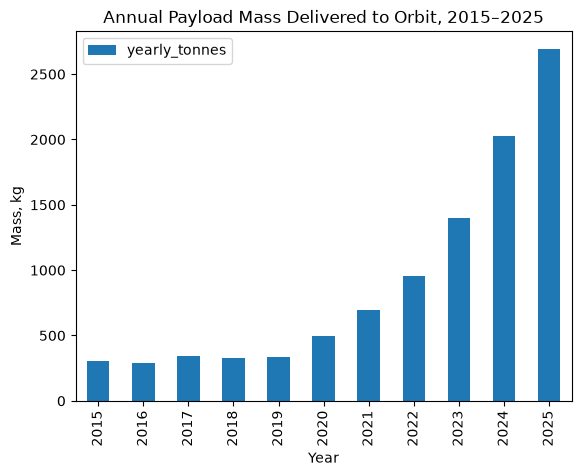

In [92]:
df = con.execute("""
    SELECT SUM(mass_kg)/1000.0 AS yearly_tonnes, YEAR(launch_date) AS year
    FROM payloads
    WHERE year BETWEEN 2015 AND 2025
    GROUP BY year""").df()
df.plot(kind='bar', x='year', y='yearly_tonnes')
plt.title("Annual Payload Mass Delivered to Orbit, 2015–2025")
plt.ylabel("Mass, kg")
plt.xlabel("Year")
plt.show()

In [91]:
con.execute("""SELECT YEAR(launch_date) as year, COUNT(*) AS num_launches, SUM(mass_kg)/1000.0 AS yearly_tonnes,(SUM(mass_kg)/1000.0)/COUNT(*) AS tonnes_per_payload_by_year 
FROM payloads
WHERE year BETWEEN 2015 AND 2025
GROUP BY year""").df()

,year,num_launches,yearly_tonnes,tonnes_per_payload_by_year
0,2015,232,306.484165,1.321052
1,2016,215,285.734250,1.328997
2,2017,443,339.540810,0.766458
3,2018,460,325.088562,0.706714
4,2019,478,332.119934,0.694812
5,2020,1248,495.951624,0.397397
6,2021,1813,698.320392,0.385174
7,2022,2448,956.397324,0.390685
8,2023,2900,1398.416275,0.482213
9,2024,2827,2028.386478,0.717505
